In [1]:
import geojson
import icepack
import numpy as np
import rasterio
import icepack.plot
import subprocess
import icepack.meshing
import firedrake
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
larsen = "data/geojson/thwaites.geojson"
dotson = 'data/geojson/dotson-crosson.geojson'
pig = outline_filename = icepack.datasets.fetch_outline("pine-island")

In [3]:
def get_outline(outline_filename):
    with open(outline_filename, "r") as outline_file:
        outline = geojson.load(outline_file)
        return outline

In [4]:
larsen_outline = get_outline(larsen)
dotson_outline = get_outline(dotson)
pig_outline = get_outline(pig)

In [5]:
δ = 10000e3
coords_larsen = np.array(list(geojson.utils.coords(larsen_outline)))
coords_dotson = np.array(list(geojson.utils.coords(dotson_outline)))
coords_pig = np.array(list(geojson.utils.coords(pig_outline)))

xmin = min(coords_larsen[:, 0].min(), coords_dotson[:, 0].min(), coords_pig[:, 0].min()) - δ
xmax = max(coords_larsen[:, 0].max(), coords_dotson[:, 0].max(), coords_pig[:, 0].max()) + δ
ymin = min(coords_larsen[:, 1].min(), coords_dotson[:, 1].min(), coords_pig[:, 1].min()) - δ
ymax = max(coords_larsen[:, 1].max(), coords_dotson[:, 1].max(), coords_pig[:, 1].max()) + δ

In [55]:
def subplots(*args, **kwargs):
    fig, axes = icepack.plot.subplots(*args, **kwargs)
    xmin, ymin, xmax, ymax = rasterio.windows.bounds(window, transform)
    
    # Create a colormap that maps black to turquoise
    cmap = mcolors.ListedColormap(['turquoise'] + [plt.cm.Greys_r(i) for i in range(1, 256)])
    
    kw = {
        "extent": (xmin, xmax, ymin, ymax),
        "cmap": cmap,
        "vmin": 12e3,
        "vmax": 16.38e3,
    }
    try:
        axes.imshow(image, **kw)
    except AttributeError:
        for ax in axes:
            ax.imshow(image, **kw)

    return fig, axes


In [56]:
outlines = {
    "larsen": larsen_outline,
    "dotson": dotson_outline,
    "pig": pig_outline
}

for name, outline in outlines.items():
    geometry = icepack.meshing.collection_to_geo(outline)
    geo_filename = f"{name}.geo"
    msh_filename = f"{name}.msh"
    
    with open(geo_filename, "w") as geo_file:
        geo_file.write(geometry.get_code())
    
    command = f"gmsh -2 -format msh2 -v 2 -o {msh_filename} {geo_filename}"
    subprocess.run(command.split())
    
    mesh = firedrake.Mesh(msh_filename)
    print(f"Mesh for {name} created.")

Mesh for larsen created.
Mesh for dotson created.
Mesh for pig created.


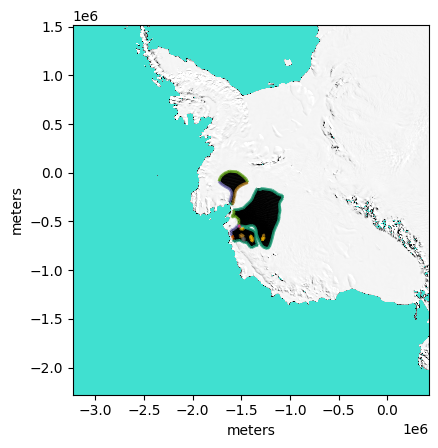

In [57]:
fig, axes = subplots()
axes.set_xlabel("meters")
axes.set_ylabel("meters")

kwargs = {
    "interior_kw": {"linewidth": 0.25},
    "boundary_kw": {"linewidth": 2},
}

for name in outlines.keys():
    mesh = firedrake.Mesh(f"{name}.msh")
    firedrake.triplot(mesh, axes=axes, **kwargs)

In [1]:
import matplotlib.pyplot as plt
from src.invert_c_theta import Invert
import pandas as pd
import firedrake
from src.helper_functions import plot_bounded_antarctica

2025-10-29 18:36:56.535316: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 18:36:56.540359: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-29 18:36:56.553984: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761763016.576457   88415 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761763016.582964   88415 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-29 18:36:56.607259: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
name_list=['data/geophysics/ADMAP_MagneticAnomaly_5km.tif', 
                                                'data/geophysics/ANTGG_BouguerAnomaly_10km_MF_combined_2.tif', 
                                                'data/geophysics/GeothermalHeatFlux_5km.tif',
                                                'data/geophysics/ALBMAP_SurfaceAirTemperature_5km.tif',
                                                'data/geophysics/EIGEN-6C4_GravityDisturbance_10km.tif',
                                                'data/geophysics/ALBMAP_SnowAccumulation_Arthern_5km.tif',
                                                'data/geophysics/Englacial_temp_Pattyn_2013.tif']

In [3]:
# drichlet_ids = [1,2,5,6,7,8,9,10,11] #dotson-crosson.geojson
# drichlet_ids = [1,2,3,4,5,6,7,9,10,11,12,13,14,15] #dotson-crosson-v1.geojson
drichlet_ids = [1,2,5,6,7,8,9,10,11]
side_ids = []
invert_dotson = Invert(outline = 'data/geojson/dotson-crosson.geojson', mesh_name = 'dotson',reg_constant_c  = 0.05, read_mesh = False,opts = None, drichlet_ids = drichlet_ids , lcar = 9e3)
invert_dotson.import_velocity_data(constant_val=0.01)
invert_dotson.import_geophysics_data(name_list=name_list)

Reading local outline
Creating mesh
Reading mesh
Reading bedmachine data
Initializing function spaces
Initializing 3d function spaces
Initializing fields
Defining friction law
Setting ramp power to :  1
Initializing heat transport
Reading velocity from measures database
C0 is constant: 0.01
Defining friction law
Defining friction law
using englacial temperature for rate factor
Geophysics data imported


In [4]:
drichlet_ids = [2,3,4]
side_ids = []
invert_pig = Invert(outline = 'pine-island', mesh_name = 'pig', reg_constant_c  = 0.05, read_mesh = False,opts = None, drichlet_ids = drichlet_ids , lcar = 9e3)
invert_pig.import_velocity_data(constant_val=0.01)
invert_pig.import_geophysics_data(name_list = name_list)


Reading outline from icepack database
Creating mesh
Reading mesh
Reading bedmachine data
Initializing function spaces
Initializing 3d function spaces
Initializing fields
Defining friction law
Setting ramp power to :  1
Initializing heat transport
Reading velocity from measures database
C0 is constant: 0.01
Defining friction law
Defining friction law
using englacial temperature for rate factor
Geophysics data imported


In [5]:
drichlet_ids = [1,2,5,6]
side_ids = []
invert_thwaites = Invert(outline = 'data/geojson/thwaites.geojson', mesh_name = 'thwaites', reg_constant_c  = 0.05, read_mesh = False,opts = None, drichlet_ids = drichlet_ids , lcar = 9e3)
invert_thwaites.import_velocity_data(constant_val=0.01)
invert_thwaites.import_geophysics_data(name_list=name_list)

Reading local outline
Creating mesh
Reading mesh
Reading bedmachine data
Initializing function spaces
Initializing 3d function spaces
Initializing fields
Defining friction law
Setting ramp power to :  1
Initializing heat transport
Reading velocity from measures database
C0 is constant: 0.01
Defining friction law
Defining friction law
using englacial temperature for rate factor
Geophysics data imported


In [9]:
def plot_all_glaciers(invert_dotson, invert_pig, invert_thwaites, variable_name = "englacial_temp",title_name = 'Englacial Temperature',vmin = None, vmax= None, δ =  1000e3):
    fig, axes = plot_bounded_antarctica(invert_thwaites.outline, δ)
    fig.set_size_inches(12, 8)
    axes.set_xlabel("UPS x [m]", fontsize=18) 
    #axes.set_ylabel("UPS y [m]", fontsize=18)  # Adjust font size for y-axis label
    axes.tick_params(axis='x', labelsize=18)  # Adjust font size for x-axis ticks
    axes.tick_params(axis='y', labelsize=18) 

    colors = None
    for invert in [invert_dotson, invert_pig, invert_thwaites]:
        colors = firedrake.tripcolor(
            getattr(invert, variable_name), vmin=vmin, vmax=vmax, axes=axes
        )
    cbar = fig.colorbar(colors, ax=axes)
    #cbar.ax.tick_params(labelsize=16)  # Set font size for colorbar ticks
    cbar.set_label('°C', fontsize=18, rotation=0) #, labelpad=20)  # Keep label upright
    #axes.set_title(title_name)

In [7]:
invert_dotson.compute_driving_stress()
invert_pig.compute_driving_stress()
invert_thwaites.compute_driving_stress()
invert_dotson.compute_mag_s()
invert_pig.compute_mag_s()
invert_thwaites.compute_mag_s()
invert_dotson.compute_mag_h()
invert_pig.compute_mag_h()
invert_thwaites.compute_mag_h()
# invert_dotson.compute_mag_b()
# invert_pig.compute_mag_b()  
# invert_thwaites.compute_mag_b()

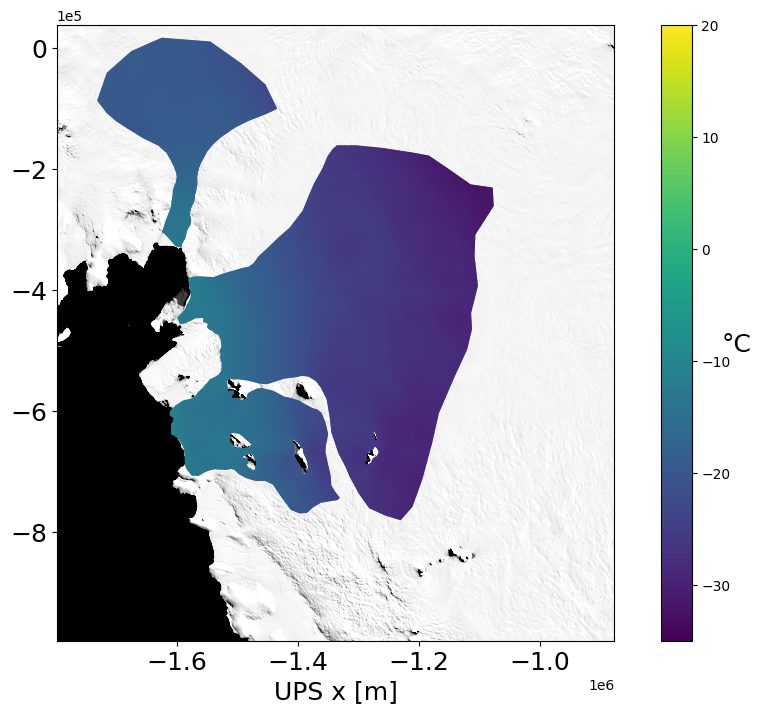

In [10]:
plot_all_glaciers(invert_dotson, invert_pig, invert_thwaites, variable_name = "surface_air_temp",title_name = 'None',vmin = -35, vmax= 20, δ =  200e3)

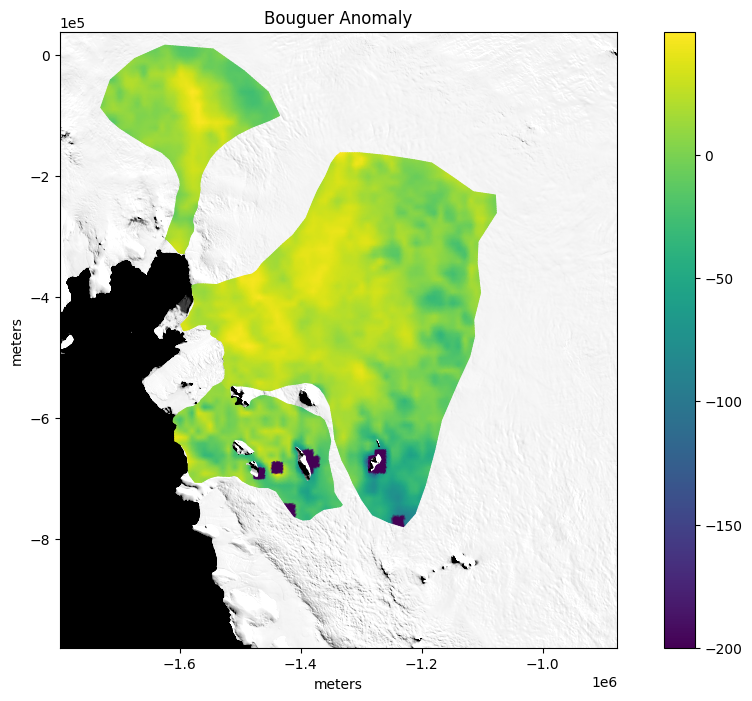

In [ ]:
# original Bouguer Anomaly
plot_all_glaciers(invert_dotson, invert_pig, invert_thwaites, variable_name = "boug_anomaly",title_name = 'Bouguer Anomaly',vmin = -200, vmax= None, δ =  200e3)